Post-processing eccentricity posterior using [gw_eccentricity](https://github.com/vijayvarma392/gw_eccentricity)<br>
In this example, we use an MCMC parameter estimation result file from [Bilby](https://git.ligo.org/lscsoft/bilby)

In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Path to PE result file

In [3]:
result_file = "/Users/arif/Desktop/TEOB_chi0_9_ecc0_3_samples.hdf5"

## Post-process the posterior file

For postprocessing Bilby result, we will use the derived class `PostProcessForBilby`

In [5]:
from gw_eccentricity.posterior.post_process_for_bilby import PostProcessForBilby

## create a datadict generator

In addition to the posterior result file, we need to provide a `data_dict_generator` function which given an index, representing a row in the posterior DataFrame, returns a data_dict that will be used to measure eccentricity using `gw_eccentricity.measure_eccentricity`

The intrinsic parameters (reference frequency, masses, spins, eccentricity and mean anomaly) should match the parameters used to generate the waveforms when using bilby

In [9]:
import sys
sys.path.append("/Users/arif/teobresums_reviewed/Python/")

In [10]:
import EOBRun_module

In [11]:
def modes_to_k(modes):
    return [int(x[0]*(x[0]-1)/2 + x[1]-2) for x in modes]

In [12]:
modes = modes_to_k([[2, 2]])
modes

[1]

In [13]:
def get_modes_dict(**pars):
    parameters = {
        # System parametes, assuming aligned spins        
        'M'                  : pars["mass_1"] + pars["mass_2"],      # Total mass
        'q'                  : pars["mass_1"]/pars["mass_2"],      # Mass ratio m1/m2 > 1
        'chi1'               : pars["a_1"],     # Z component of chi_1
        'chi2'               : pars["a_2"],     # Z component of chi_2
        'LambdaAl2'          : 0.,     # Quadrupolar tidal parameter of body 1 (A)
        'LambdaBl2'          : 0.,     # Quadrupolar tidal parameter of body 2 (B)
        'ecc'                : pars["eccentricity"],     # Eccentricity. Default = 0.
        'ecc_freq'           : 2,      # Use periastron (0), average (1) or apastron (2) frequency for initial condition computation. Default = 1

        # Initial conditions and output time grid
        'domain'             : 0,      # Time domain. EOBSPA is not available for eccentric waveforms!
        'srate_interp'       : int(1/pars["dt"]),  # srate at which to interpolate. Default = 4096.
        'use_geometric_units': "no",   # output quantities in geometric units. Default = 1
        'initial_frequency'  : pars["minimum_frequency"],     # in Hz if use_geometric_units = 0, else in geometric units
        'interp_uniform_grid': "yes",  # interpolate mode by mode on a uniform grid. Default = 0 (no interpolation)

        # Modes
        'use_mode_lm'        : [1],    # List of modes to use/output through EOBRunPy

        # Output parameters (Python)
        'arg_out'            : "yes",  # Output hlm/hflm. Default = 0
    }
    t, _, _, hlm, dyn = EOBRun_module.EOBRunPy(parameters)
    data_dict = {"t": t,
                 "hlm": {(2, 2): hlm['1'][0]*np.exp(-1j * hlm['1'][1]),}}
    return data_dict

In [14]:
def dataDict_generator(sample_index, posterior, **kwargs):
    params = posterior.iloc[sample_index]
    variables = ['mass_1', 'mass_2', 'eccentricity', "a_1", "a_2"]
    var_dict = {"dt": 1/4096,
               "minimum_frequency": 10}
    for k in variables:
        var_dict[k] = params[k]
    return get_modes_dict(**var_dict)

Check that the data_dict generated using `dataDict_generator` makes sense

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Posteriors

Now we use the posterior result file and the `data_dict_generator` to instantiate an instance of  `PostProcessForBilby` class

In [17]:
egwBilby = PostProcessForBilby(result_file, dataDict_generator)

18:59 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


# Looking at the original posteriors

In [18]:
egwBilby.get_posterior()

18:59 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


,H1_log_likelihood,H1_matched_filter_snr,H1_optimal_snr,L1_log_likelihood,L1_matched_filter_snr,L1_optimal_snr,L1_time,V1_log_likelihood,V1_matched_filter_snr,V1_optimal_snr,a_1,a_2,chi_1,chi_1_in_plane,chi_2,chi_2_in_plane,chi_eff,chi_p,chirp_mass,chirp_mass_source,comoving_distance,cos_tilt_1,cos_tilt_2,dec,eccentricity,geocent_time,iota,log_likelihood,log_prior,luminosity_distance,mass_1,mass_1_source,mass_2,mass_2_source,mass_ratio,mean_per_ano,minimum_frequency,phase,phi_1,phi_12,phi_2,phi_jl,psi,ra,redshift,reference_frequency,spin_1x,spin_1y,spin_1z,spin_2x,spin_2y,spin_2z,symmetric_mass_ratio,theta_jn,tilt_1,tilt_2,total_mass,total_mass_source,waveform_approximant
0,623.536988,35.393036- 1.832653j,36.320440,832.897895,40.886870+ 0.337570j,41.362264,2.022867,79.990989,12.783959+ 0.292588j,13.283787,0.892924,0.840667,0.892924,0.0,0.840667,0.0,0.871493,0.0,50.358002,37.525509,1388.614593,1.0,1.0,-0.482732,0.340209,2.001635,0.254826,1540.545248,-19.113001,1863.475251,69.606326,51.868873,48.389912,36.058937,0.695194,2.603613,10.0,0.136975,0.0,0.0,0.0,0.0,1.301536,3.380185,0.341967,10.0,0,0,0.892924,0,0,0.840667,0.241917,0.254826,0.0,0.0,117.996238,87.927810,TEOBResumSDALI
1,623.737121,35.413042- 0.219257j,36.072400,834.313813,40.934172+ 0.893366j,40.930566,2.020499,78.126882,12.680335- 1.206002j,12.763677,0.860734,0.884071,0.860734,0.0,0.884071,0.0,0.871188,0.0,50.688752,39.701549,1143.310134,1.0,1.0,-0.481010,0.339408,1.999270,0.799544,1541.333516,-17.825065,1459.715426,64.705539,50.680083,52.509656,41.127758,0.811517,3.756373,10.0,2.096833,0.0,0.0,0.0,0.0,0.449314,3.370383,0.276745,10.0,0,0,0.860734,0,0,0.884071,0.247294,0.799544,0.0,0.0,117.215195,91.807840,TEOBResumSDALI
2,625.263228,35.442456- 1.632387j,35.903969,829.859150,40.812956- 0.412181j,40.807886,2.023034,82.320345,12.970347+ 0.254119j,13.072128,0.886695,0.756452,0.886695,0.0,0.756452,0.0,0.835221,0.0,49.547654,36.905864,1390.733819,1.0,1.0,-0.486112,0.345114,2.001799,0.189148,1541.698708,-17.804144,1867.117849,70.723160,52.678566,46.216547,34.424670,0.653485,2.279949,10.0,2.997747,0.0,0.0,0.0,0.0,1.375050,3.377535,0.342541,10.0,0,0,0.886695,0,0,0.756452,0.239020,0.189148,0.0,0.0,116.939708,87.103236,TEOBResumSDALI
3,623.660924,35.395494- 2.728341j,34.966475,833.187739,40.892780+ 2.002818j,40.065281,2.020089,81.065828,12.864432+ 0.454741j,12.946800,0.841869,0.868357,0.841869,0.0,0.868357,0.0,0.853811,0.0,50.814009,37.381486,1452.397971,1.0,1.0,-0.470935,0.318437,1.998870,0.161180,1541.986693,-18.163762,1974.297198,64.484123,47.437948,52.938299,38.944227,0.820951,0.244970,10.0,4.968558,0.0,0.0,0.0,0.0,0.311332,3.387386,0.359336,10.0,0,0,0.841869,0,0,0.868357,0.247583,0.161180,0.0,0.0,117.422422,86.382175,TEOBResumSDALI
4,627.470438,35.506280+ 0.409910j,35.208147,830.505277,40.830341- 0.528652j,39.797103,2.020817,79.868891,12.782441+ 0.623043j,12.668456,0.808252,0.812520,0.808252,0.0,0.812520,0.0,0.809946,0.0,48.926640,36.503479,1382.562257,1.0,1.0,-0.496341,0.340370,1.999575,0.230434,1542.140286,-16.175043,1853.087114,69.566824,51.902830,45.800200,34.170886,0.658363,0.608621,10.0,1.696649,0.0,0.0,0.0,0.0,0.614103,3.370708,0.340328,10.0,0,0,0.808252,0,0,0.812520,0.239390,0.230434,0.0,0.0,115.367024,86.073716,TEOBResumSDALI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12723,626.550917,35.499546+ 0.073499j,36.098698,845.009001,41.201355+ 0.036744j,40.760186,2.020851,82.309320,13.023293- 0.098106j,13.410467,0.893773,0.885188,0.893773,0.0,0.885188,0.0,0.889512,0.0,51.742774,41.394241,1040.055297,1.0,1.0,-0.495873,0.308731,1.999608,0.951851,1559.300037,-19.720308,1300.068425,59.868980,47.895210,59.008436,47.206774,0.985626,0.136035,10.0,4.462924,0.0,0.0,0.0,0.0,0.632878,3.375420,0.249999,10.0,0,0,0.893773,0,0,0.885188,0.249987,0.951851,0.0,0.0,118.877416,95.101984,TEOBResumSDA

In [19]:
len(egwBilby.get_posterior())

18:59 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


12728

(<Figure size 600x400 with 1 Axes>, <Axes: >)

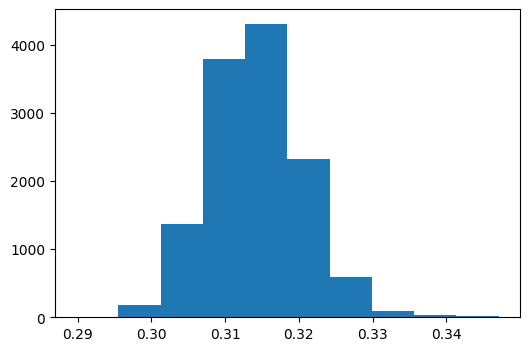

In [20]:
egwBilby.plot_eccentricity_posterior(**{"bins": 10})

In [44]:
posterior_samples = egwBilby.get_posterior()

19:09 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


In [48]:
data_dict = egwBilby.get_data_dict(0)

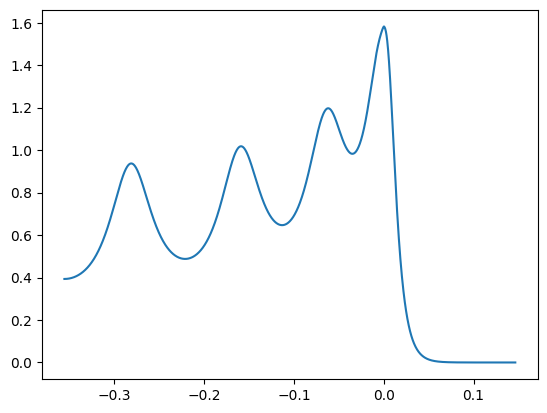

In [49]:
plt.plot(data_dict["t"], np.abs(data_dict["hlm"][(2, 2)]))

# Post-processing

In [37]:
fref = 24
egwBilby.post_process(fref=fref, samples=np.arange(0, 20), method="AmplitudeFits")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 21.73it/s]


[{'sample_index': np.int64(0),
  'method': 'AmplitudeFits',
  'fref': 24,
  'status': 'fail',
  'eccentricity': None,
  'mean_anomaly': None,
  'error_message': Exception('Number of pericenters found = 0.\nCan not build frequency interpolant through the pericenters.\n')},
 {'sample_index': np.int64(1),
  'method': 'AmplitudeFits',
  'fref': 24,
  'status': 'fail',
  'eccentricity': None,
  'mean_anomaly': None,
  'error_message': Exception('Number of pericenters found = 0.\nCan not build frequency interpolant through the pericenters.\n')},
 {'sample_index': np.int64(2),
  'method': 'AmplitudeFits',
  'fref': 24,
  'status': 'fail',
  'eccentricity': None,
  'mean_anomaly': None,
  'error_message': Exception('Number of pericenters found = 0.\nCan not build frequency interpolant through the pericenters.\n')},
 {'sample_index': np.int64(3),
  'method': 'AmplitudeFits',
  'fref': 24,
  'status': 'fail',
  'eccentricity': None,
  'mean_anomaly': None,
  'error_message': Exception('Number of

In [38]:
egwBilby.post_process_result

[{'sample_index': np.int64(0),
  'method': 'AmplitudeFits',
  'fref': 24,
  'status': 'fail',
  'eccentricity': None,
  'mean_anomaly': None,
  'error_message': Exception('Number of pericenters found = 0.\nCan not build frequency interpolant through the pericenters.\n')},
 {'sample_index': np.int64(1),
  'method': 'AmplitudeFits',
  'fref': 24,
  'status': 'fail',
  'eccentricity': None,
  'mean_anomaly': None,
  'error_message': Exception('Number of pericenters found = 0.\nCan not build frequency interpolant through the pericenters.\n')},
 {'sample_index': np.int64(2),
  'method': 'AmplitudeFits',
  'fref': 24,
  'status': 'fail',
  'eccentricity': None,
  'mean_anomaly': None,
  'error_message': Exception('Number of pericenters found = 0.\nCan not build frequency interpolant through the pericenters.\n')},
 {'sample_index': np.int64(3),
  'method': 'AmplitudeFits',
  'fref': 24,
  'status': 'fail',
  'eccentricity': None,
  'mean_anomaly': None,
  'error_message': Exception('Number of

In [39]:
gwecc_posterior = egwBilby.get_egw_posterior()

Text(0.5, 0, '$e_{\\mathrm{gw}}$')

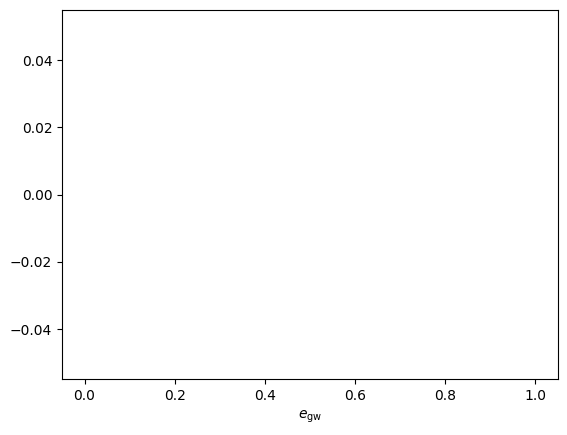

In [40]:
plt.hist(gwecc_posterior["eccentricity"])
plt.xlabel("$e_{\mathrm{gw}}$")

## Get a summary of the post-process, like how many cases were successfully post-processed

In [41]:
egwBilby.post_process_summary()

{'total_samples': 20,
 'success_percentage': 0.0,
 'fref': 24,
 'method': 'AmplitudeFits',
 'eccentricity': [],
 'mean_anomaly': []}

## Getting the best fref to use
Sometimes the chosen `fref` could be outside the range where `egw` can be measured. Running the following code will give an idea of the `fref` bounds withing which majority of the samples can be post-processed

In [42]:
egwBilby.get_fref_bounds_for_sample(0)

{'sample_index': 0,
 'method': 'Amplitude',
 'status': 'success',
 'fref_min': np.float64(23.29754977735529),
 'fref_max': np.float64(26.735330872849136)}

In [43]:
egwBilby.get_fref_bounds(samples=np.arange(0, 20))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 22.79it/s]


{'fref_bounds': (np.float64(23.82369979556528), np.float64(25.80996553598021)),
 'success_percentage': 100.0,
 'failed_cases': []}